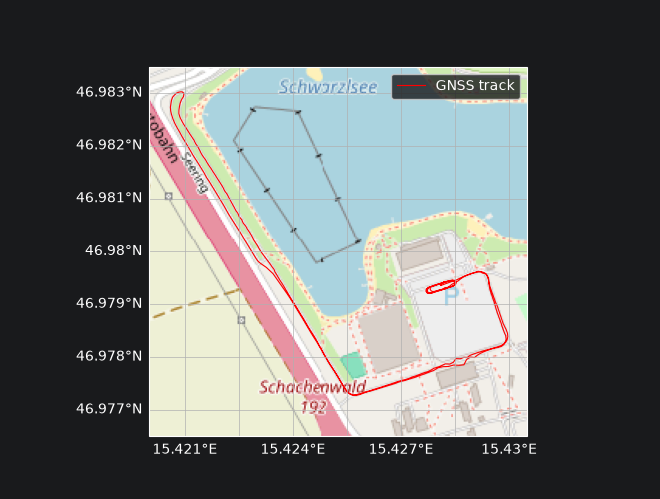

In [88]:
import settings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import importlib
importlib.reload(settings)

def read_gnss():
    raw = open(settings.gnss_file, 'r', encoding='iso-8859-1').readlines()
    gnss_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    gnss_data = np.array(gnss_data)
    return gnss_data

def plot_gnss(gnss_data):
    cimgt_request = cimgt.OSM()
    ax = plt.axes(projection=cimgt_request.crs)
    ax.set_extent(settings.lat_lon_plotting_bounds)
    ax.add_image(cimgt_request, 15)

    plt.plot(gnss_data[:, 2], gnss_data[:, 1], transform=ccrs.PlateCarree(), linewidth=0.8, color='red', label='GNSS track')

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('GNSS Track')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()


gnss_data = read_gnss()
plot_gnss(gnss_data)


In [89]:

def read_imu():
    raw = open(settings.imu_file, 'r', encoding='iso-8859-1').readlines()
    imu_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    imu_data = np.array(imu_data)
    return imu_data

imu_data = read_imu()